# `==== Atelier Seaborn ====`

### `0.4 Installation et importation de seaborn, matplotlib, pandas et numpy`

In [25]:
# terminal: pip install seaborn matplotlib pandas numpy

# Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### `0.5 Importation des mesures des capteurs`

In [26]:
df = pd.read_csv("../data/mesures_capteurs.csv")


### `0.6 Vérification du contenu du dataframe`

In [27]:
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## `Partie 0: Analyse exploratoire: ADA`

In [28]:
# Information du dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [29]:
# Vérification de la dimension
print(df.shape)
# Verification des statistiques descriptives
df.describe()

(605, 9)


,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [30]:
# Suppression des duplications
df.drop_duplicates(inplace=True)
df.shape

(600, 9)

In [7]:
# Remplissage des valeurs manquantes pour les floats:

On remarque que les colonnes `temperature`, `humidite`, `pression`, `consommation` et `etat` contiennent des valeurs manquantes.

Dans un premier temps on gere les foats:

apres analyse on remarque que l'ecart-type et la moyenne pour les colonnes de type floats sont très éloignés et il en est de même pour les min et les max: donc on remplace les valeurs manquantes par la mediane qui est moins sensible aux valeurs abérantes.

In [31]:
# colonne température
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
# Colonne consommation
df['consommation'] = df['consommation'].fillna(df['consommation'].median())
# Colonne humidite
df['humidite'] = df['humidite'].fillna(df['humidite'].median())
# Colonne pression
df['pression'] = df['pression'].fillna(df['pression'].median())
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     600 non-null    str    
 1   date_heure    600 non-null    str    
 2   id_capteur    600 non-null    str    
 3   batiment      600 non-null    str    
 4   temperature   600 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          596 non-null    str    
dtypes: float64(4), str(5)
memory usage: 46.9 KB


In [32]:
df["etat"].mode()

0    OK
Name: etat, dtype: str

In [33]:
df["etat"] = df["etat"].fillna("OK")
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     0
humidite        0
pression        0
consommation    0
etat            0
dtype: int64

## `Partie 1 – Distribution d'une variable avec histplot()`

### `1.1 Distribution des températures`

<Axes: xlabel='temperature', ylabel='Count'>

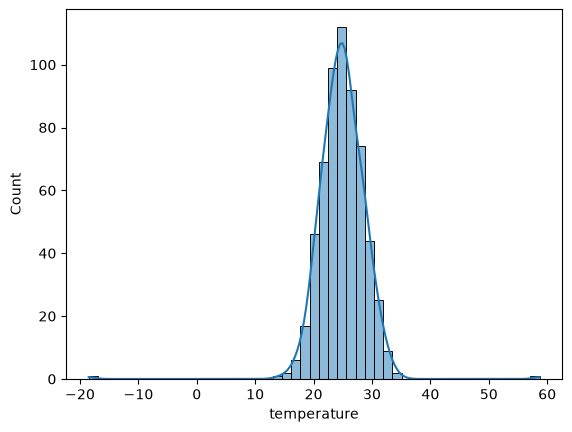

In [45]:
sns.histplot(data=df, x="temperature", kde=True)
 

### `1.2 Autour de quelle valeur les températures sont concentrées ?`

La majorité des valeurs se concentrent entre 20°C et 30°C, avec un pic net
autour de 24-25°C (barre la plus haute, ~112 observations).

### ` 1.3 La distribution semble-t-elle symétrique ? `

Oui, dans sa partie centrale (15-35°C) la distribution a une forme de
cloche assez symétrique, proche d'une loi normale. Ce n'est cependant pas
parfaitement symétrique : on note une légère queue plus étalée vers les
basses valeurs (jusqu'à ~12°C) que vers les hautes.

### ` 1.4 Existe-t-il des valeurs extrêmes ? `

Oui, clairement deux outliers isolés et très éloignés du reste de la
distribution : une valeur autour de -18°C et une autre autour de 58°C.
Ces deux points sont physiquement suspects (probablement des erreurs de
capteur/saisie plutôt que de vraies mesures) et méritent d'être vérifiés
avant toute analyse plus poussée.

### ` 1.5 Modification du nombre de classes`



<Axes: xlabel='temperature', ylabel='Count'>

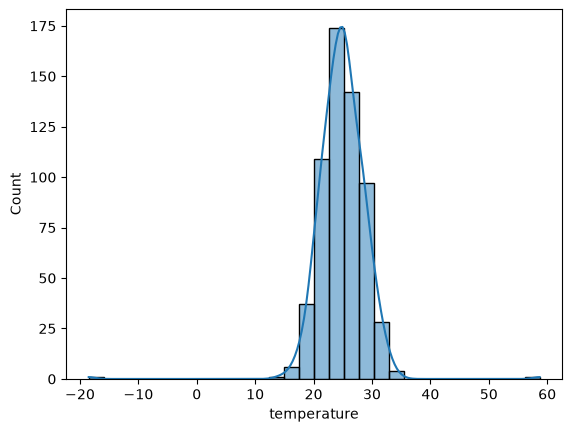

In [48]:
sns.histplot(data=df, x="temperature", bins=30, kde=True)


### `1.6 la distribution des températures par bâtiment`

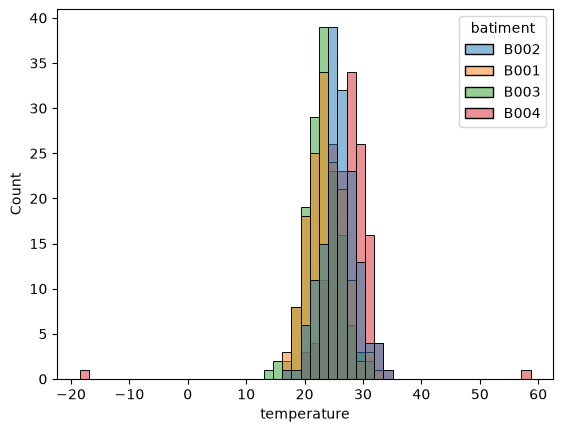

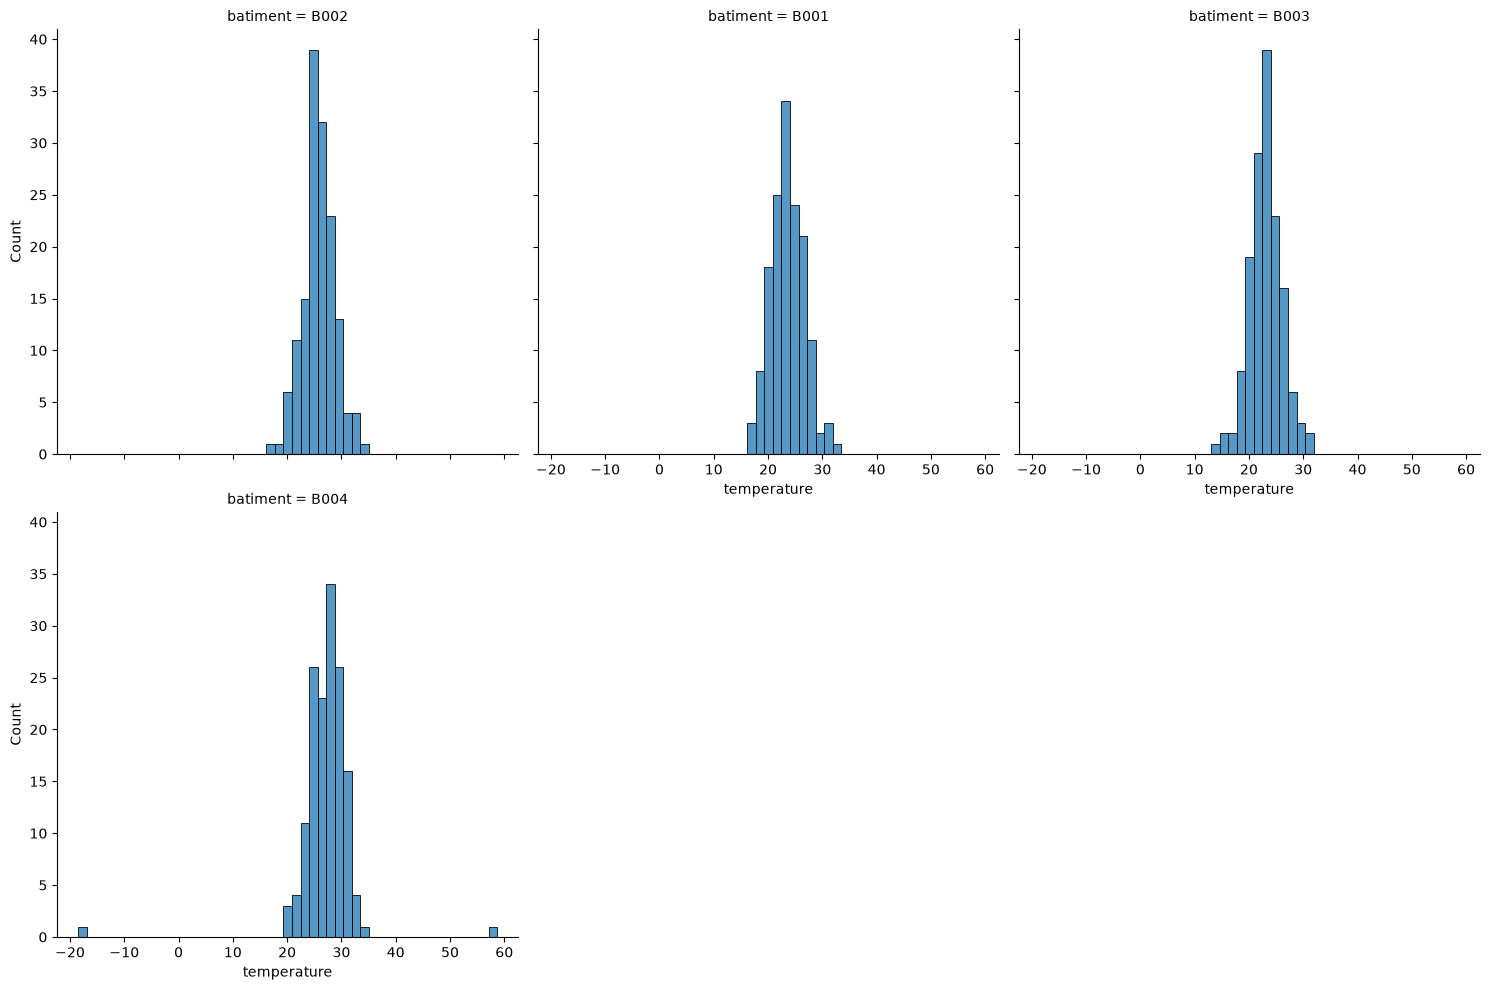

In [43]:
sns.histplot(data=df, x='temperature', hue='batiment', stat='count')
sns.displot(data=df, x='temperature', col='batiment', kind="hist", col_wrap=3)

## `Partie 2 – Distribution d'une variable avec kdeplot()`

### `2.1 Affichage de la distribution des températures`

<Axes: xlabel='temperature', ylabel='Density'>

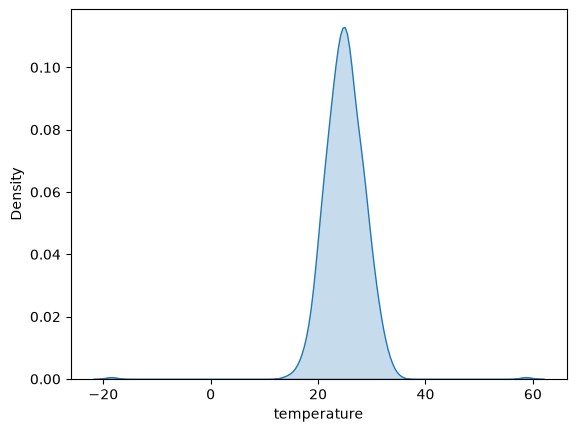

In [ ]:
sns.kdeplot(data=df, x="temperature", fill=True )

### `2.2 Affichage la distribution des températures par batiment`


<Axes: xlabel='temperature', ylabel='Density'>

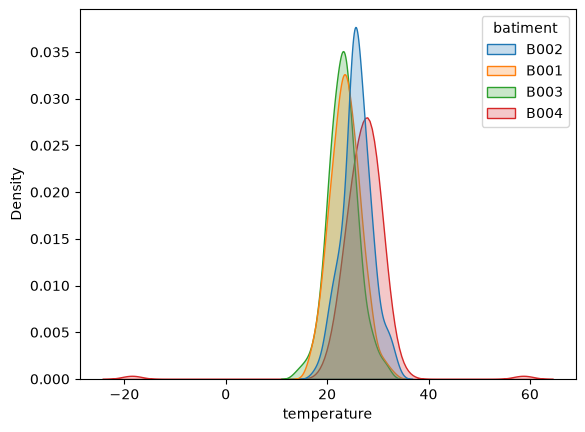

In [56]:
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True )

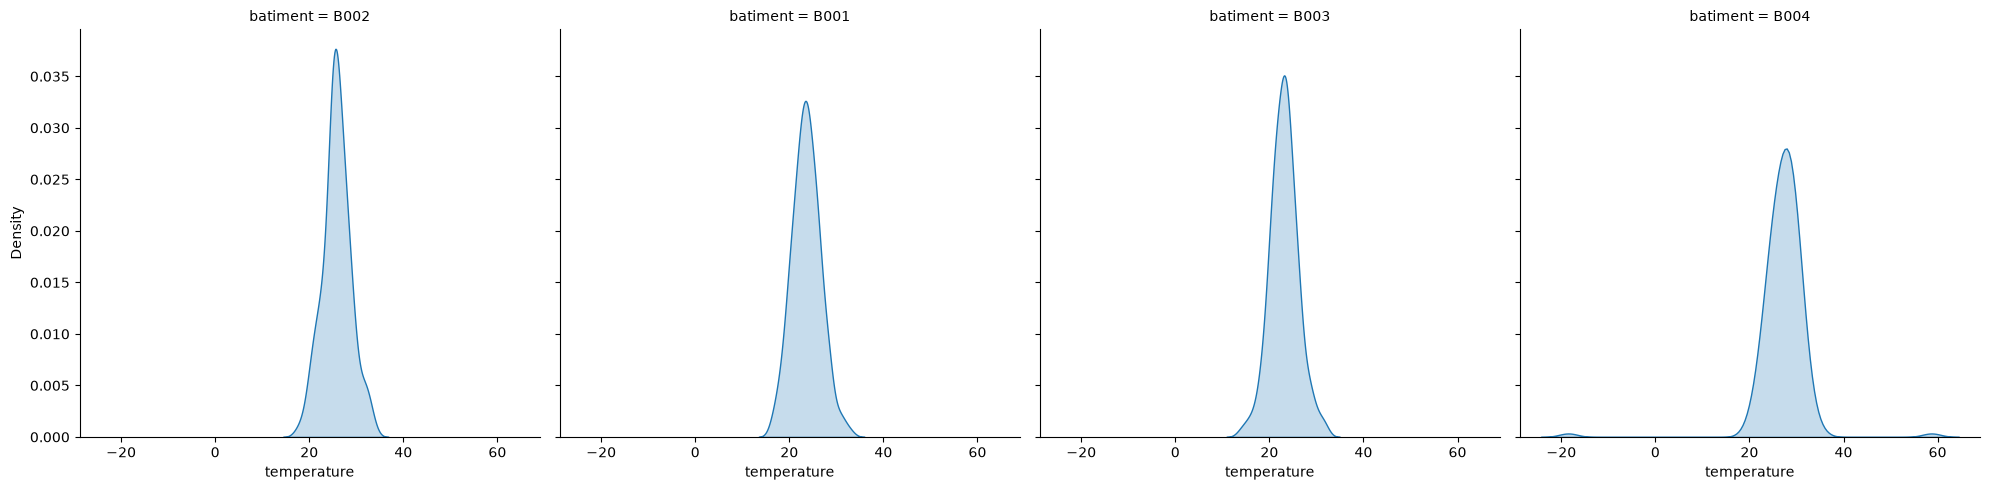

In [57]:
sns.displot(data=df, x='temperature', col='batiment', kind="kde", fill=True, col_wrap=4)

## `Partie 3 – Distribution d'une variable avec boxplot()`

### `3.1: Affichage de la distribution des températures`

Text(0.5, 1.0, 'Distribution de la temperature')

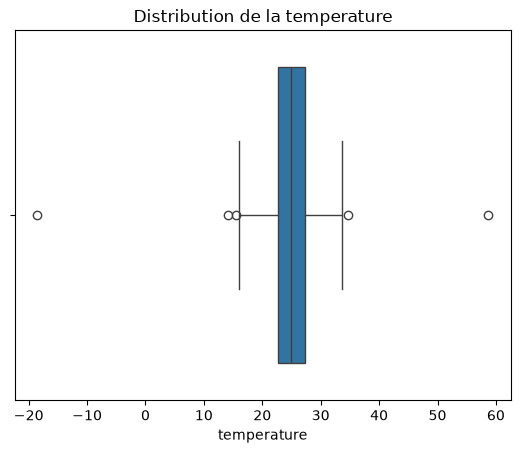

In [61]:
sns.boxplot(data=df, x="temperature")
plt.title("Distribution de la temperature")

### `3.2: Afficher la distribution des températures par bâtiment`

Text(0.5, 1.0, 'Distributiuon de la température par Batiment')

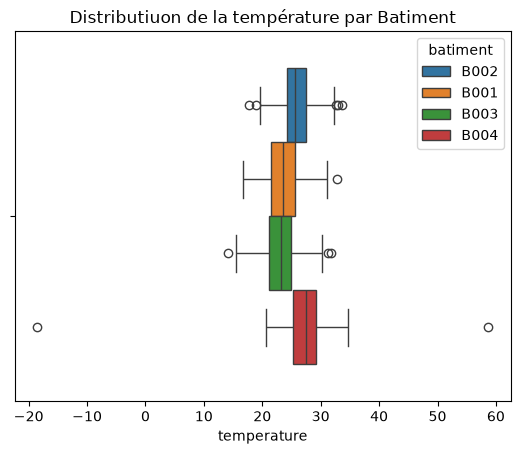

In [91]:

sns.boxplot(data=df, x="temperature", hue="batiment")

plt.title("Distributiuon de la température par Batiment")

### `3.3 Pour chaque bâtiment, on donne:`

#### `3.3.a: La médiane ?`

Text(0.5, 1.0, 'Distributiuon de la température par Batiment')

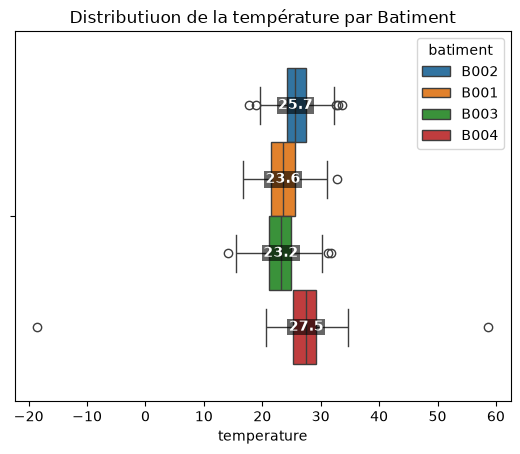

In [89]:
# On fixe l'ordre des classe
order = df["batiment"].unique()

ax = sns.boxplot(data=df, x="temperature", hue="batiment", hue_order=order)

# Recumération de la mediane de chaque batiment
medians = df.groupby("batiment")["temperature"].median()

# on parcours 

for patch, batiment in zip(ax.patches, order):
    bbox = patch.get_path().get_extents()
    y_centre = (bbox.y0 + bbox.y1) / 2
    valeur = medians[batiment]
    ax.text(
        valeur, y_centre,
        f"{valeur:.1f}",
        ha="center", va="center",
        fontweight="bold", color="white",
        bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=1)
    )

plt.title("Distributiuon de la température par Batiment")

In [95]:
df.groupby("batiment")["temperature"].median()

batiment
B001    23.555
B002    25.670
B003    23.175
B004    27.535
Name: temperature, dtype: float64

#### `3.3.b: La Dispersion ?`


Pour la dispersion, les deux indicateurs les plus utilisés avec un boxplot sont l'écart-type et l'IQR (l'écart interquartile, qui est justement ce que représente visuellement la hauteur de chaque boîte).

In [98]:
dispersion = df.groupby('batiment')['temperature'].agg(
     ecart_type="std",
     q1 = lambda x: x.quantile(0.25),
     q3 = lambda x: x.quantile(0.50),
)

dispersion['IQR'] = dispersion['q3'] - dispersion['q1']
dispersion

,ecart_type,q1,q3,IQR
batiment,,,,
B001,2.980308,21.5725,23.555,1.9825
B002,2.951828,24.2675,25.670,1.4025
B003,2.958831,21.0950,23.175,2.0800
B004,5.331180,25.1750,27.535,2.3600


#### `3.3.c: Les valeurs extrêmes ?`


In [132]:
q1 = df.groupby("batiment")["temperature"].transform(lambda x: x.quantile(0.25))
q3 = df.groupby("batiment")["temperature"].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

outliers = df[(df["temperature"] < q1 - 1.5 * iqr) | (df["temperature"] > q3 + 1.5 * iqr)]
outliers = outliers[["batiment", "temperature"]]
# Batiment B001
B001 = outliers[outliers['batiment'] == 'B001']
# Batiment B002
B002 = outliers[outliers['batiment'] == 'B002']
# Batiment B003
B003 = outliers[outliers['batiment'] == 'B003']
# Batiment B004
B004 = outliers[outliers['batiment'] == 'B004']

print(B001)
print(B002)
print(B003)
print(B004)

    batiment  temperature
520     B001        32.72
    batiment  temperature
118     B002        32.90
129     B002        33.60
213     B002        18.85
438     B002        32.56
506     B002        17.67
    batiment  temperature
174     B003        31.74
245     B003        14.11
280     B003        31.30
    batiment  temperature
487     B004        -18.5
502     B004         58.7


### `3.4 Les bâtiments qui ont les valeurs les plus extrêmes ?`

`B004` est le bâtiment qui a les valeurs les plus extrêmes.

Il présente deux outliers dont l'amplitude dépasse largement celle de
tous les autres bâtiments : `-18.5°C` et `58.7°C`. À titre de comparaison,
les outliers des autres bâtiments (`B001`, `B002`, `B003`) restent tous
compris entre `~14°C` et `~34°C` — un écart bien plus faible par rapport
à la distribution générale des températures (concentrée autour de
`20-30°C`).

Ces deux valeurs de `B004` sont donc les seules à sortir franchement de
la plage physiquement plausible, ce qui en fait le bâtiment aux
valeurs les plus extrêmes du jeu de données.

## `Partie 4 – Distribution d'une variable avec violinplot()`

### `4.1 Affichage de la distribution des températures`

Text(0.5, 1.0, 'Distribution de la température')

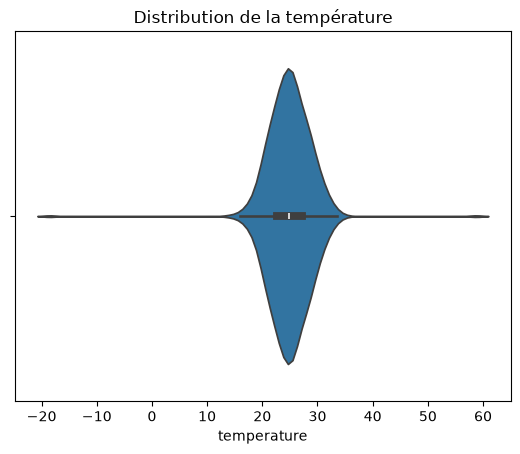

In [138]:
sns.violinplot(data=df, x=df["temperature"] )
plt.title("Distribution de la température")

### `4.2: Affichage de la distribution des températures par bâtiment`

Text(0.5, 1.0, 'Distribution de la température par batiment')

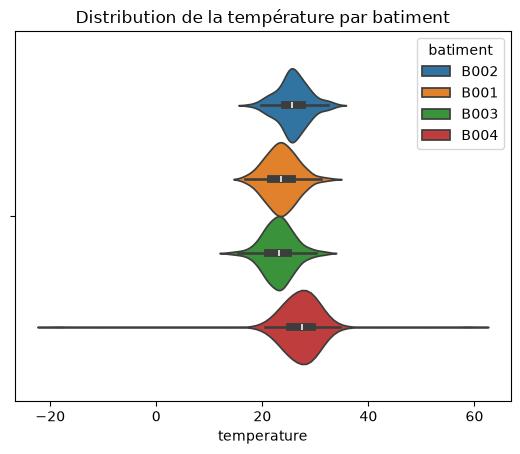

In [135]:
sns.violinplot(data=df, x=df["temperature"], hue="batiment" )
plt.title("Distribution de la température par batiment")

### `4.3: Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ?`

Le violin plot montre en plus la forme complète de la distribution
(grâce à une courbe de densité), là où le boxplot ne montre que
quelques statistiques (min, quartiles, médiane, max). Il permet donc
de voir si les données ont un ou plusieurs pics (bimodalité), et où
elles sont le plus concentrées — des détails invisibles sur un
simple boxplot.

## `Partie 5 – Comptage des catégories avec countplot()`

### `5.1: Affichage du nombre de mesures par état`

<Axes: xlabel='etat', ylabel='count'>

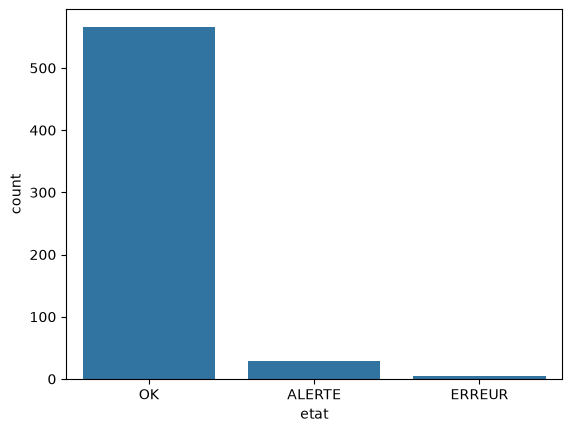

In [139]:
sns.countplot(data=df, x="etat")

### `5.2: Affichage du nombre de mesures par bâtiment`

Text(0.5, 1.0, 'Distribution des états par Batiment')

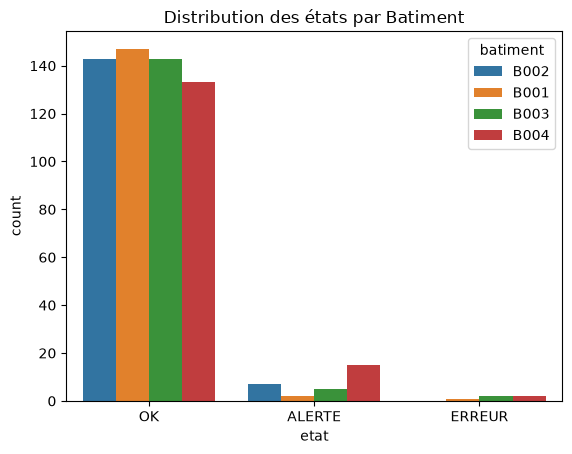

In [142]:
sns.countplot(data=df, x="etat", hue='batiment')
plt.title("Distribution des états par Batiment")

### `5.3: Affichage des états des capteurs par bâtiment pour identifier:`

`a. le bâtiment ayant le plus de mesures en état OK ;`

Text(0.5, 1.0, 'Alertes et erreurs par bâtiment')

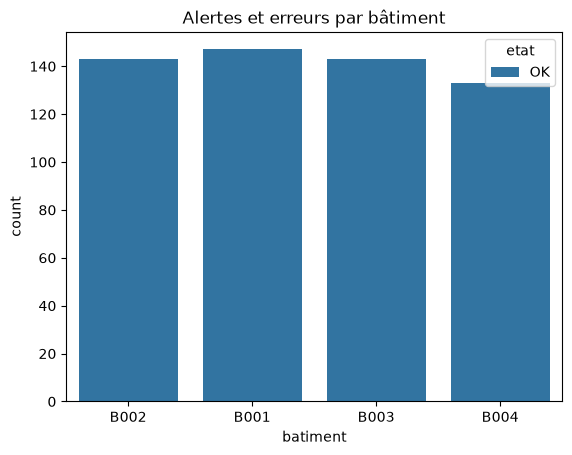

In [150]:
sns.countplot(data=df[df["etat"] == "OK"], x="batiment", hue="etat")
plt.title("Alertes et erreurs par bâtiment")

Text(0.5, 1.05, 'Distribution des états par bâtiment')

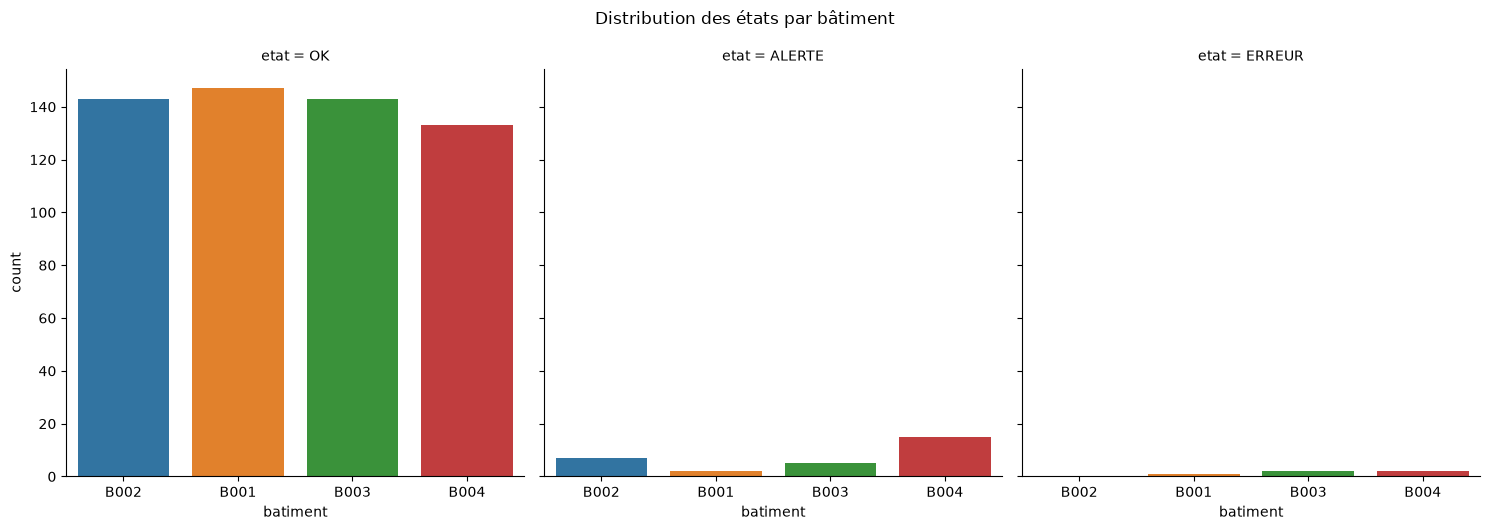

In [152]:
sns.catplot(data=df, x="batiment", col="etat",hue="batiment", kind="count")
plt.suptitle("Distribution des états par bâtiment", y=1.05)

## `Partie 6 – Relation entre deux variables avec scatterplot()`

### `6.1: Etudier graphiquement la relation entre température et consommation`

<Axes: xlabel='temperature', ylabel='consommation'>

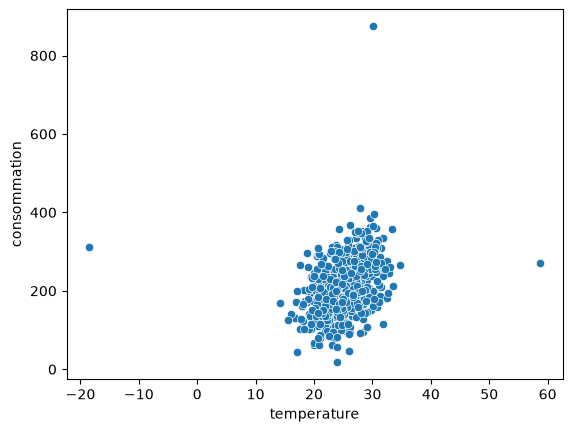

In [ ]:
sns.scatterplot(data=df, x="temperature", y="consommation" )
plt.title("")

### `6.2: Etudier graphiquement la relation entre température et consommation par bâtiment`

<Axes: xlabel='temperature', ylabel='consommation'>

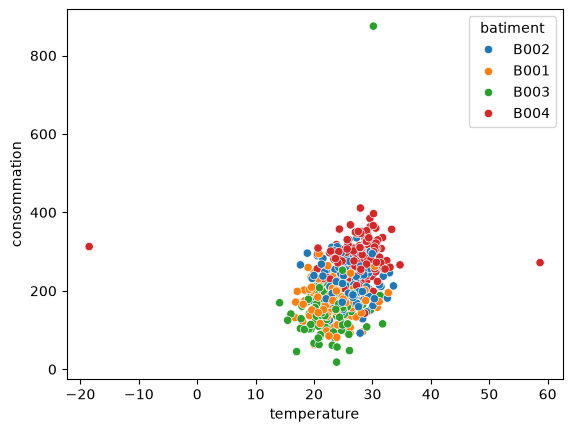

In [ ]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment")


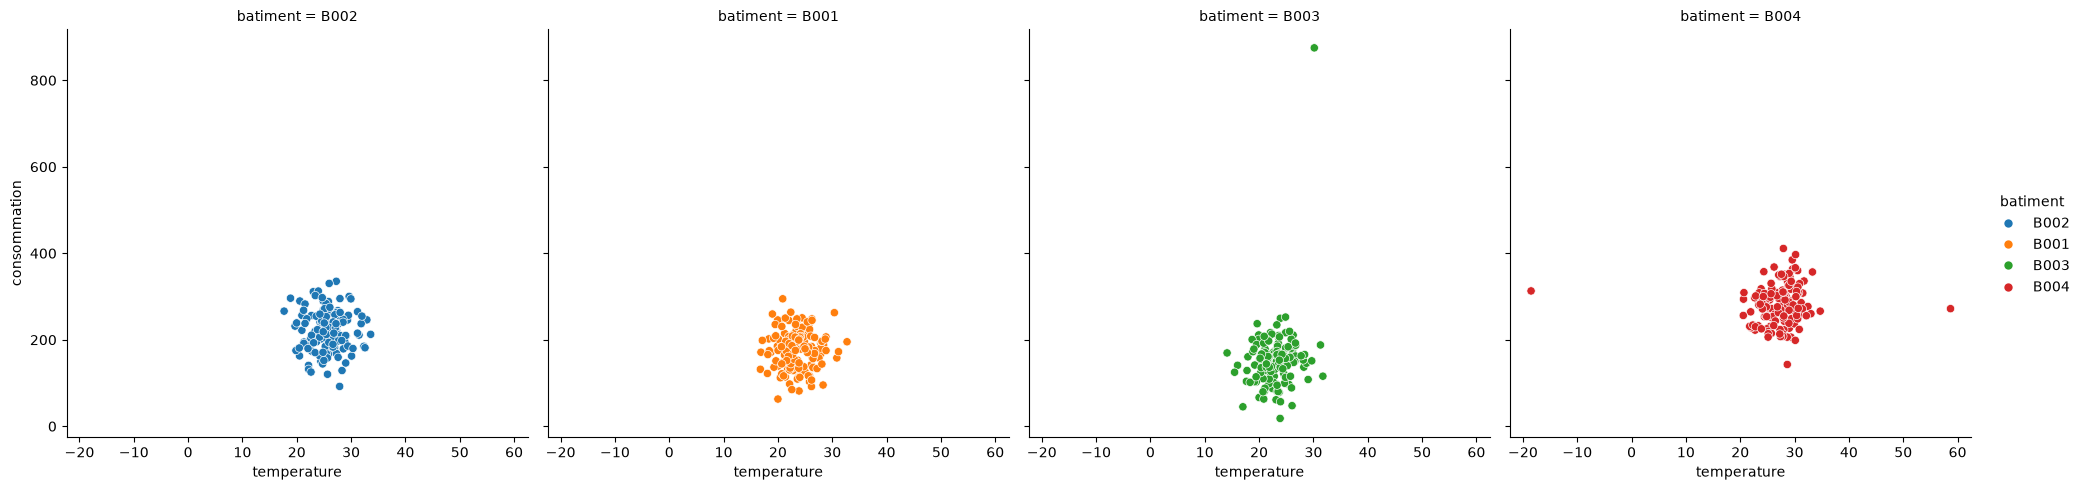

In [166]:
# Alternative avec relplot
sns.relplot(data=df, x="temperature", y="consommation", col="batiment", hue="batiment", kind="scatter", col_wrap=4)

### `6.3: Modification de la taille des points`

<Axes: xlabel='temperature', ylabel='consommation'>

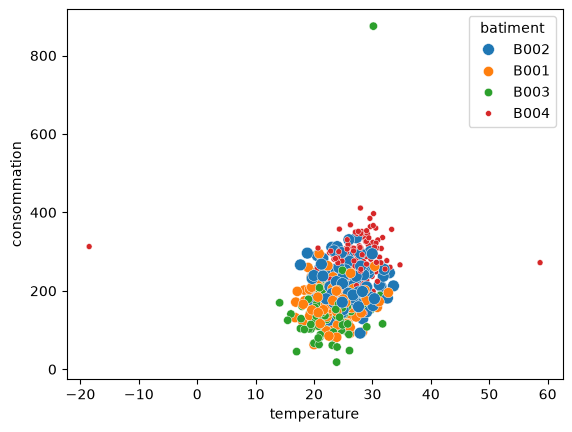

In [169]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", size='batiment')


## `Partie 7 – Régression avec regplot()`

### `7.1: Etude graphique de la tendance entre température et consommation`

<Axes: xlabel='temperature', ylabel='consommation'>

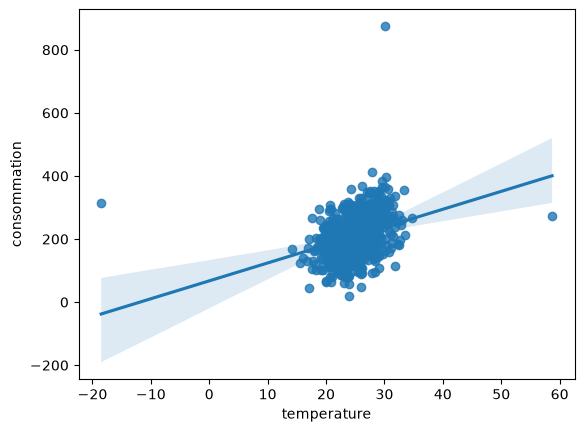

In [170]:
sns.regplot(data=df, x="temperature", y="consommation")

In [171]:
# Corrélation globale  
print(df["temperature"].corr(df["consommation"]))

0.31905515200645596


La droite de régression indique une tendance positive : la
consommation augmente légèrement avec la température. Mais le nuage
de points est très dispersé autour de la droite, et le coefficient de
corrélation (0.32) confirme une relation faible à modérée — la
température seule n'explique donc qu'une petite partie des variations
de consommation. Les valeurs extrêmes (-18.5°C, 58.7°C, et le point à
~875) élargissent fortement l'intervalle de confiance et influencent
la pente, ce qui fragilise encore la fiabilité de cette tendance.

## `Partie 8 – Régression avec lmplot()`

### `8.1: On Etudie graphiquement la tendance entre température et consommation par bâtiment`

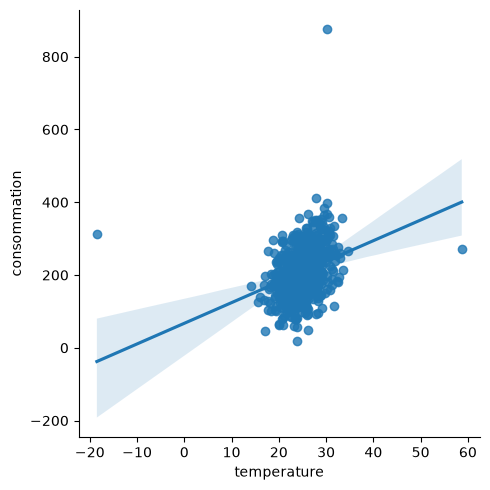

In [177]:
sns.lmplot(data=df, x="temperature", y="consommation",)

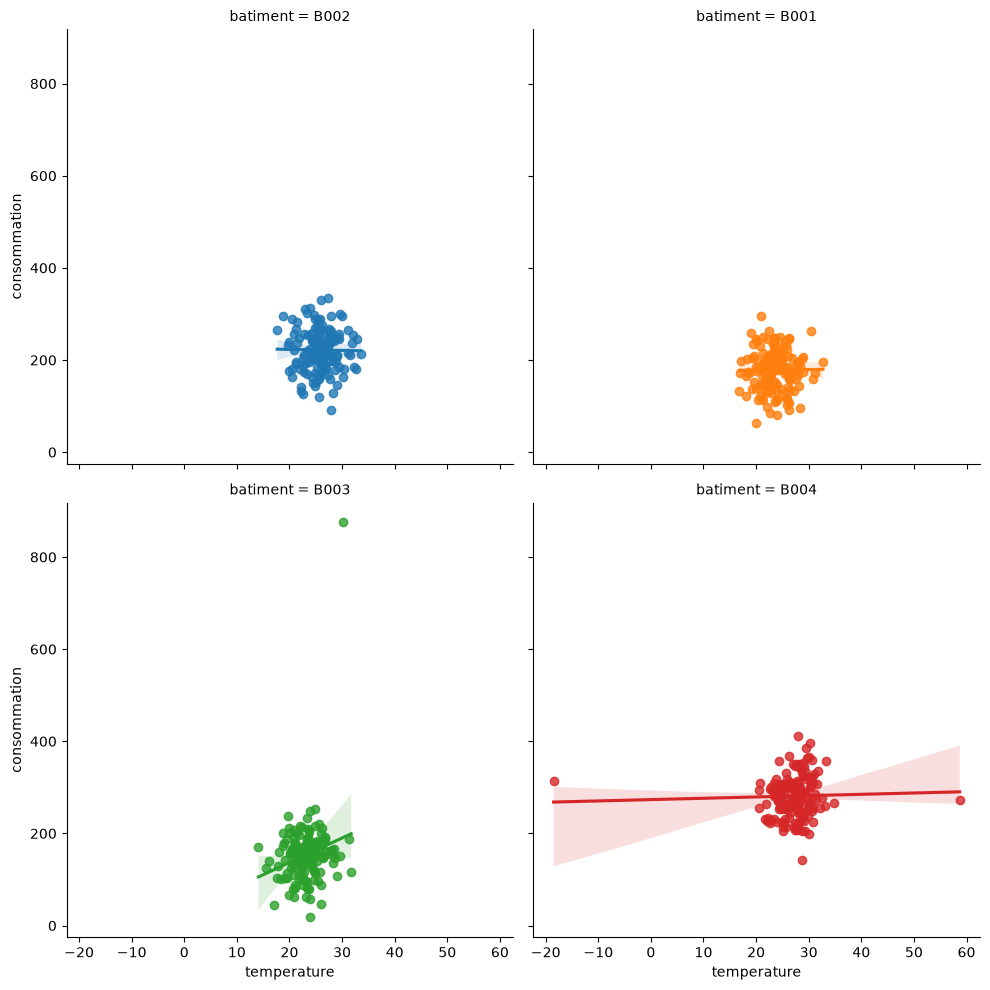

In [179]:
sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment", col="batiment", col_wrap=2)

la relation `température/consommation` n'est pas uniforme
selon les bâtiments. `B003` montre la tendance positive la plus nette,
tandis que `B001` et `B002` ne montrent quasiment aucune relation. C'est
pour cela que la tendance globale (`graphe 1`, `corrélation 0.32`) est
faible : elle mélange des comportements très différents d'un bâtiment
à l'autre, ce qui dilue le signal individuel de `B003`.